<a href="https://colab.research.google.com/github/HudaSaffo/fashion-recommendation-system/blob/feature%2Fcatalog-refinement/catalog_refinement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Catalog Category and Colour Refinement

This notebook improves the Week 2 product metadata using the transparent product cutouts created in Week 3.

It uses FashionCLIP to predict a refined product category and refined colour for each successfully segmented item. The original `category` and `color` columns are kept unchanged for comparison.

## Output

The notebook creates:

- `refined_category`
- `refined_color`

and saves the enriched catalog as:

```text
/content/drive/MyDrive/catalog_refined.parquet

In [1]:
!pip -q install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00


Saved 3,673 items to /content/drive/MyDrive/catalog_refined.parquet


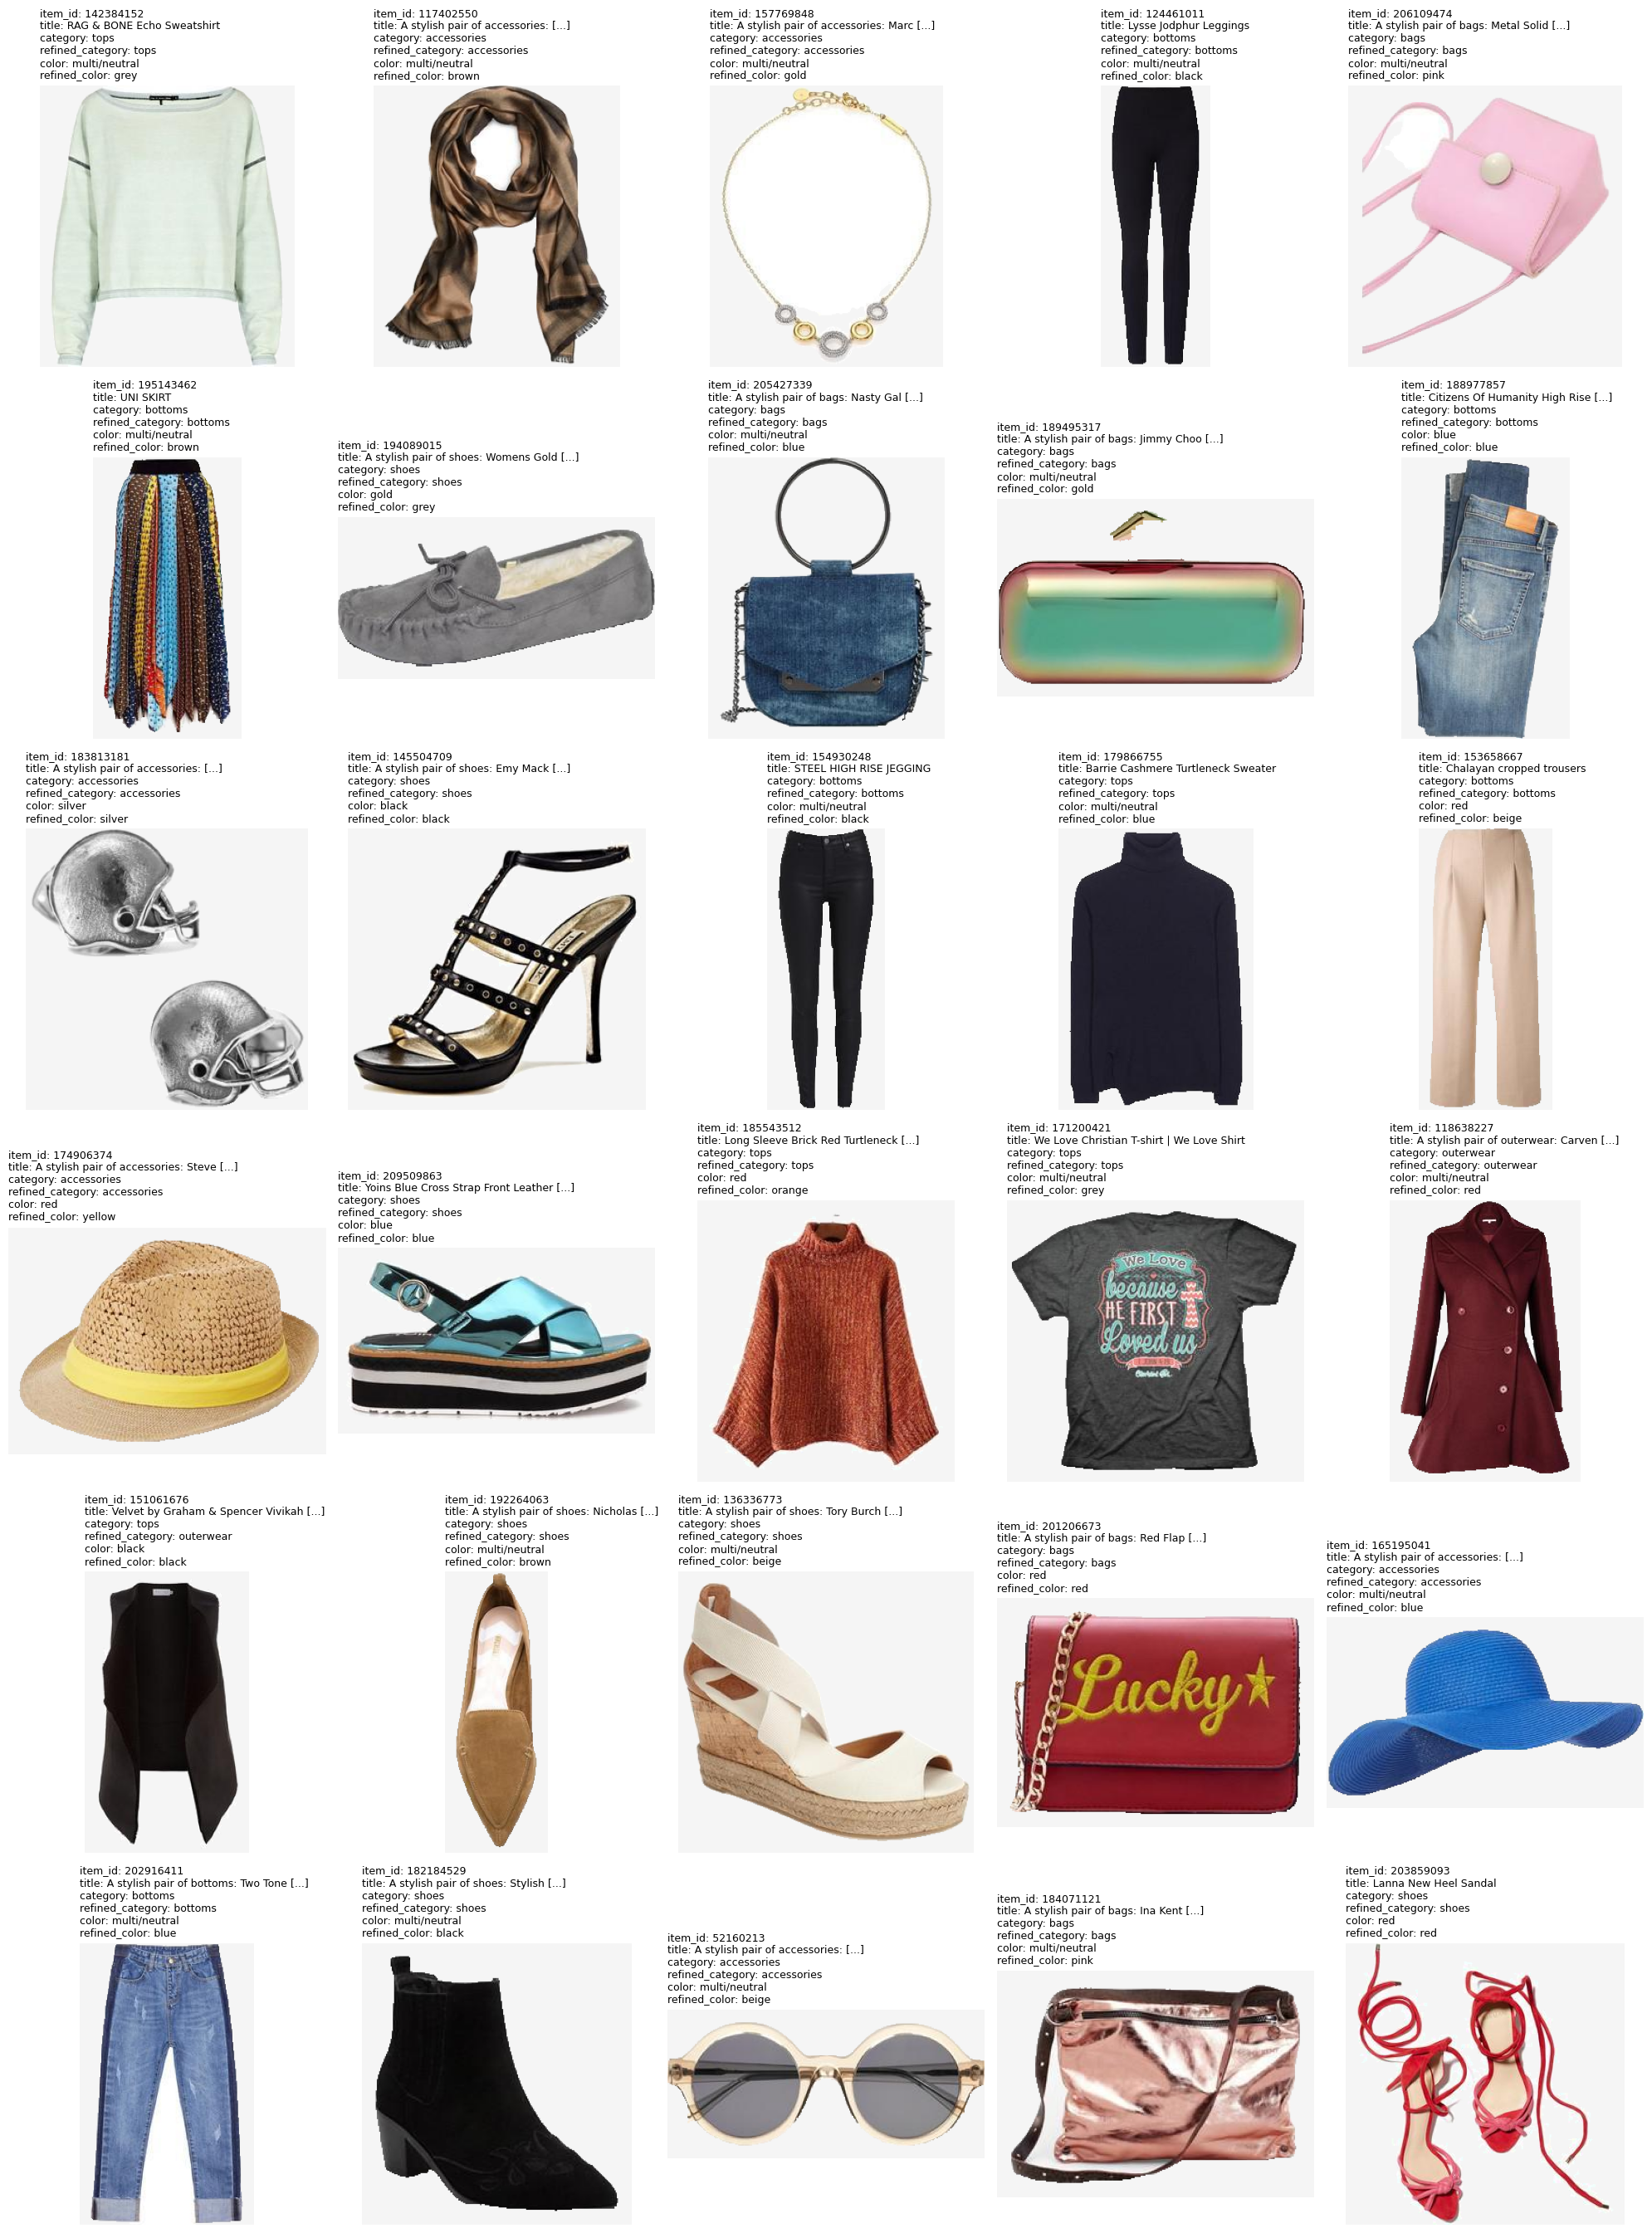

In [17]:
import textwrap
import pandas as pd
import torch
import open_clip
import matplotlib.pyplot as plt
from PIL import Image

MAX_ITEMS = None
CATEGORY_CONFIDENCE_THRESHOLD = 0.40
COLOR_MARGIN_THRESHOLD = 0.05

CATALOG_PATH = "/content/drive/MyDrive/catalog.parquet"
MANIFEST_PATH = "/content/drive/MyDrive/polyvore_segmented_cache/segmentation_manifest.csv"
OUTPUT_PATH = "/content/drive/MyDrive/catalog_refined.parquet"

MODEL_NAME = "hf-hub:Marqo/marqo-fashionCLIP"

CATEGORIES = [
    "tops", "bottoms", "shoes", "outerwear",
    "bags", "dresses", "accessories"
]

COLOR_LABELS = [
    "black", "white", "grey", "blue", "red", "green", "yellow",
    "orange", "pink", "purple", "brown", "beige", "gold", "silver"
]

CATEGORY_PROMPTS = {
    "tops": [
        "a fashion product photo of a shirt",
        "a fashion product photo of a blouse",
        "a fashion product photo of a tee",
        "a fashion product photo of a sweater",
        "a fashion product photo of a hoodie",
        "a fashion product photo of a tank top, camisole, polo shirt, tunic, or sweatshirt"
    ],
    "bottoms": [
        "a fashion product photo of jeans",
        "a fashion product photo of trousers",
        "a fashion product photo of pants",
        "a fashion product photo of a skirt",
        "a fashion product photo of shorts",
        "a fashion product photo of leggings",
        "a fashion product photo of joggers, sweatpants, culottes, or a midi skirt"
    ],
    "shoes": [
        "a fashion product photo of sneakers",
        "a fashion product photo of shoes",
        "a fashion product photo of boots",
        "a fashion product photo of heels",
        "a fashion product photo of sandals",
        "a product photo of platform sandals or wedge sandals",
        "a product photo of loafers, mules, or slide sandals",
        "a product photo of espadrilles"
    ],
    "outerwear": [
        "a fashion product photo of a jacket",
        "a fashion product photo of a coat",
        "a fashion product photo of a blazer",
        "a fashion product photo of a cardigan",
        "a fashion product photo of a vest",
        "a fashion product photo of a trench coat, parka, cape, or sleeveless vest"
    ],
    "bags": [
        "a fashion product photo of a handbag",
        "a fashion product photo of a purse",
        "a fashion product photo of a tote bag",
        "a fashion product photo of a clutch bag",
        "a fashion product photo of a backpack",
        "a product photo of a crossbody bag, shoulder bag, satchel, wallet, or cosmetic pouch"
    ],
    "dresses": [
        "a fashion product photo of a dress",
        "a fashion product photo of a gown",
        "a fashion product photo of a jumpsuit",
        "a fashion product photo of a romper",
        "a fashion product photo of a maxi dress, midi dress, mini dress, sundress, or playsuit"
    ],
    "accessories": [
    "a fashion product photo of jewellery",
    "a fashion product photo of a watch",
    "a fashion product photo of a belt",
    "a fashion product photo of a scarf",
    "a fashion product photo of a hat",
    "a fashion product photo of sunglasses",
    "a fashion product photo of earrings",
    "a product photo of dangling earrings or fashion jewellery",
    "a fashion product photo of a hat",
    "a product photo of a straw sun hat or wide-brim hat",
    "a product photo of a baseball cap, bucket hat, or fedora",
    "a product photo of a necklace, bracelet, ring, hair accessory, or gloves"
    "a product photo of a straw sun hat, wide-brim hat, baseball cap, bucket hat, or fedora"
],
}

COLOR_PROMPTS = {
    color: [
        f"a fashion product that is primarily {color}",
        f"a product photo of {color} clothing or a {color} fashion accessory",
    ]
    for color in COLOR_LABELS
}

catalog = pd.read_parquet(CATALOG_PATH)
manifest = pd.read_csv(
    MANIFEST_PATH,
    usecols=["item_id", "cutout_path"]
)

catalog["item_id"] = catalog["item_id"].astype(str)
manifest["item_id"] = manifest["item_id"].astype(str)

work = catalog.merge(
    manifest[["item_id", "cutout_path"]],
    on="item_id",
    how="inner"
)

if MAX_ITEMS is not None:
    work = work.sample(
        n=min(MAX_ITEMS, len(work)),
        random_state=42
    ).reset_index(drop=True)


def open_cutout(path):
    cutout = Image.open(path).convert("RGBA")
    background = Image.new(
        "RGBA",
        cutout.size,
        (245, 245, 245, 255)
    )
    return Image.alpha_composite(background, cutout).convert("RGB")


device = "cuda" if torch.cuda.is_available() else "cpu"

model, _, preprocess = open_clip.create_model_and_transforms(MODEL_NAME)
tokenizer = open_clip.get_tokenizer(MODEL_NAME)
model = model.to(device).eval()


def averaged_text_features(labels, prompts):
    averaged_features = []

    with torch.inference_mode():
        for label in labels:
            features = model.encode_text(
                tokenizer(prompts[label]).to(device)
            )
            features /= features.norm(dim=-1, keepdim=True)

            averaged = features.mean(dim=0)
            averaged /= averaged.norm()
            averaged_features.append(averaged)

    return torch.stack(averaged_features)


category_features = averaged_text_features(
    CATEGORIES,
    CATEGORY_PROMPTS
)

color_features = averaged_text_features(
    COLOR_LABELS,
    COLOR_PROMPTS
)

category_predictions = []
category_confidences = []
color_predictions = []

batch_size = 64

for start in range(0, len(work), batch_size):
    paths = work["cutout_path"].iloc[start:start + batch_size]

    images = torch.stack([
        preprocess(open_cutout(path)) for path in paths
    ]).to(device)

    with torch.inference_mode():
        image_features = model.encode_image(images)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        category_probabilities = (
            model.logit_scale.exp()
            * image_features
            @ category_features.T
        ).softmax(dim=-1)

        category_confidence, category_index = (
            category_probabilities.max(dim=-1)
        )

        color_probabilities = (
            model.logit_scale.exp()
            * image_features
            @ color_features.T
        ).softmax(dim=-1)

        top_color_probabilities, top_color_indices = (
            color_probabilities.topk(2, dim=-1)
        )

    category_predictions.extend(
        CATEGORIES[index]
        for index in category_index.cpu().tolist()
    )
    category_confidences.extend(
        category_confidence.cpu().tolist()
    )

    for scores, indices in zip(
        top_color_probabilities.cpu().tolist(),
        top_color_indices.cpu().tolist()
    ):
        margin = scores[0] - scores[1]

        if margin < COLOR_MARGIN_THRESHOLD:
            color_predictions.append("multi/neutral")
        else:
            color_predictions.append(COLOR_LABELS[indices[0]])


work["refined_category"] = [
    prediction
    if confidence >= CATEGORY_CONFIDENCE_THRESHOLD
    else original
    for prediction, confidence, original in zip(
        category_predictions,
        category_confidences,
        work["category"]
    )
]

work["refined_color"] = color_predictions

result = work[
    list(catalog.columns)
    + ["refined_category", "refined_color"]
]

result.to_parquet(OUTPUT_PATH, index=False)
print(f"Saved {len(result):,} items to {OUTPUT_PATH}")

examples = work.sample(
    n=min(30, len(work)),
    random_state=5
)

fig, axes = plt.subplots(6, 5, figsize=(20, 27))
axes = axes.flatten()

for ax, (_, row) in zip(axes, examples.iterrows()):
    ax.imshow(open_cutout(row["cutout_path"]))
    ax.axis("off")
    ax.set_title(
        f"item_id: {row['item_id']}\n"
        f"title: {textwrap.shorten(str(row['title']), width=42)}\n"
        f"category: {row['category']}\n"
        f"refined_category: {row['refined_category']}\n"
        f"color: {row['color']}\n"
        f"refined_color: {row['refined_color']}",
        fontsize=9,
        loc="left"
    )

for ax in axes[len(examples):]:
    ax.axis("off")

plt.tight_layout()
plt.show()